# 04 — Final Model and Bundle

Reconstruct the model selected in notebook 03, fit it once on `train + validation`, evaluate the sealed `test` partition exactly once, and materialize a declarative educational inference bundle. This stage does not perform model selection, tuning, threshold selection, API implementation, or operational validation.


## 1. Finalization Context

The final candidate, preprocessing contract, hyperparameters, feature order, target encoding, and educational threshold are frozen from the validated notebook 03 handoff before any evaluative access to `test`.


In [1]:
from __future__ import annotations

import copy
import hashlib
import json
import sys
import time
from pathlib import Path


def _bootstrap_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "scripts" / "finalize_model.py").is_file():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory.")

PROJECT_ROOT = _bootstrap_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import nbformat
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier

from scripts.finalize_model import (
    EvaluationGuard,
    assemble_final_training_data,
    evaluate_final_model_once,
    freeze_finalization_decisions,
    inspect_final_artifact_set,
    load_and_validate_final_model_handoff,
    load_and_validate_inference_bundle,
    load_test_partition_after_freeze,
    load_trusted_pipeline_from_bundle,
    reconstruct_selected_pipeline,
    sha256_file,
    validate_existing_finalization_equivalence,
    validate_upstream_handoff_contracts,
    verify_pipeline_contract,
    write_final_model_artifacts,
)
from scripts.select_models import semantic_fingerprint_csv, semantic_fingerprint_json

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.figsize"] = (8, 5)
print("Finalization utilities loaded.")

Finalization utilities loaded.


## 2. Independent Project and Runtime Loading

Discover the repository root without relying on notebook 03 kernel state. Only project-relative paths are displayed.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "scripts" / "finalize_model.py").is_file():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory.")

PROJECT_ROOT = find_project_root()
DATASET_SLUG = "telco-customer-churn"
PREPARATION_DIR = Path("artifacts/preparation") / DATASET_SLUG
MODEL_SELECTION_DIR = Path("artifacts/model-selection") / DATASET_SLUG
FINAL_DIR = Path("artifacts/models") / DATASET_SLUG
SPLIT_DIR = Path("data/processed") / DATASET_SLUG / "splits/stratified-random-snapshot-seed-42"

print("Project root: .")
print("Preparation artifacts:", PREPARATION_DIR.as_posix())
print("Model-selection artifacts:", MODEL_SELECTION_DIR.as_posix())
print("Final artifacts:", FINAL_DIR.as_posix())


Project root: .
Preparation artifacts: artifacts/preparation/telco-customer-churn
Model-selection artifacts: artifacts/model-selection/telco-customer-churn
Final artifacts: artifacts/models/telco-customer-churn


## 3. Preparation-Handoff Integrity Gate

Validate the persisted preparation manifests and CSVs through the public preparation API. Retain only `train`, `validation`, and declarative metadata after validation; the handoff object containing the in-memory `test` DataFrame is discarded.


In [3]:
PREPARATION_PATHS = {
    "preparation_manifest_path": PREPARATION_DIR / "preparation-manifest.json",
    "feature_manifest_path": PREPARATION_DIR / "feature-manifest.json",
    "split_manifest_path": PREPARATION_DIR / "split-manifest.json",
    "quality_evidence_path": PREPARATION_DIR / "quality-evidence.json",
}
MODEL_SELECTION_HANDOFF_PATH = MODEL_SELECTION_DIR / "model-selection-handoff.json"

preparation_handoff, model_selection_handoff = validate_upstream_handoff_contracts(
    project_root=PROJECT_ROOT,
    preparation_paths=PREPARATION_PATHS,
    model_selection_handoff_path=MODEL_SELECTION_HANDOFF_PATH,
)

PREPARATION_MANIFESTS = preparation_handoff.manifests
TRAIN_FRAME = preparation_handoff.train
VALIDATION_FRAME = preparation_handoff.validation
# Explicitly discard the object that also contains the structurally validated test DataFrame.
del preparation_handoff

split_manifest = PREPARATION_MANIFESTS["split_manifest"]
feature_manifest = PREPARATION_MANIFESTS["feature_manifest"]
preparation_manifest = PREPARATION_MANIFESTS["preparation_manifest"]
quality_evidence = PREPARATION_MANIFESTS["quality_evidence"]

print("Preparation handoff valid.")
print("Prepared rows:", preparation_manifest["prepared_row_count"])
print("Train rows:", split_manifest["row_counts"]["train"])
print("Validation rows:", split_manifest["row_counts"]["validation"])
print("Test metadata retained; test DataFrame discarded.")


Preparation handoff valid.
Prepared rows: 7043
Train rows: 4930
Validation rows: 1056
Test metadata retained; test DataFrame discarded.


## 4. Model-Selection-Handoff Integrity Gate

Validate the complete six-artifact model-selection set, recalculate semantic fingerprints, and confront the saved notebook 03 outputs with the persisted handoff.


In [4]:
model_selection_manifest = json.loads(
    (PROJECT_ROOT / MODEL_SELECTION_DIR / "model-selection-manifest.json").read_text(encoding="utf-8")
)
threshold_analysis = json.loads(
    (PROJECT_ROOT / MODEL_SELECTION_DIR / "threshold-analysis.json").read_text(encoding="utf-8")
)

artifact_fingerprint_checks = {}
for filename, expected in model_selection_manifest["artifact_fingerprints"].items():
    path = PROJECT_ROOT / MODEL_SELECTION_DIR / filename
    if path.suffix == ".csv":
        semantic = semantic_fingerprint_csv(pd.read_csv(path))
    else:
        semantic = semantic_fingerprint_json(json.loads(path.read_text(encoding="utf-8")))
    artifact_fingerprint_checks[filename] = {
        "byte_match": sha256_file(path) == expected["byte_sha256"],
        "semantic_match": semantic == expected["semantic_sha256"],
    }

manifest_base = copy.deepcopy(model_selection_manifest)
manifest_base.pop("self_semantic_sha256", None)
manifest_self_match = (
    semantic_fingerprint_json(manifest_base)
    == model_selection_manifest["self_semantic_sha256"]
)
assert manifest_self_match and all(
    item["byte_match"] and item["semantic_match"]
    for item in artifact_fingerprint_checks.values()
)

nb03 = nbformat.read(PROJECT_ROOT / "notebooks/03_model_selection_and_evaluation.ipynb", as_version=4)
saved_output_text = "\n".join(
    str(output.get("text", ""))
    if output.output_type == "stream"
    else str(output.get("data", {}).get("text/plain", ""))
    for cell in nb03.cells
    if cell.cell_type == "code"
    for output in cell.get("outputs", [])
)
for expected_text in (
    model_selection_handoff["selected_model_id"],
    model_selection_handoff["selected_model_family"],
    str(model_selection_handoff["selected_educational_threshold"]["threshold"]),
    str(model_selection_handoff["selected_validation_metrics"]["average_precision"]),
):
    assert expected_text in saved_output_text

print("Model-selection handoff valid.")
print("Notebook 03 outputs agree with runtime artifacts.")
print("Selected model:", model_selection_handoff["selected_model_id"])
print("Test sealed:", model_selection_handoff["test_partition_sealed"])
print("Test evaluated upstream:", model_selection_handoff["test_partition_evaluated"])
print("Final training ready:", model_selection_handoff["readiness"]["final_model_training_ready"])


Model-selection handoff valid.
Notebook 03 outputs agree with runtime artifacts.
Selected model: hist_gradient_boosting
Test sealed: True
Test evaluated upstream: False
Final training ready: True


## 5. Frozen Finalization Contract

Freeze the exact selected family, preprocessing, hyperparameters, feature roles, target encoding, and educational threshold. Check for an existing complete equivalent finalization set before any fit or test loading.


In [5]:
FINAL_CONTRACT = freeze_finalization_decisions(
    dataset_slug=DATASET_SLUG,
    model_selection_handoff=model_selection_handoff,
    identifier_columns=feature_manifest["identifier_columns"],
    target_column=feature_manifest["target_column"],
    target_classes=feature_manifest["target_classes"],
    estimator_random_state=model_selection_handoff["random_seeds"]["estimators"],
)

final_state = inspect_final_artifact_set(PROJECT_ROOT / FINAL_DIR)
if final_state == "partial":
    raise RuntimeError("Partial final artifact set detected; refusing silent repair.")
IDEMPOTENT_REUSE = final_state == "complete"
if IDEMPOTENT_REUSE:
    validate_existing_finalization_equivalence(
        output_directory=PROJECT_ROOT / FINAL_DIR,
        contract=FINAL_CONTRACT,
    )

print("Frozen model:", FINAL_CONTRACT.model_family)
print("Frozen hyperparameters:", dict(FINAL_CONTRACT.hyperparameters))
print("Frozen educational threshold:", FINAL_CONTRACT.educational_threshold)
print("Threshold origin: validation")
print("Existing final set:", final_state)


Frozen model: HistGradientBoostingClassifier
Frozen hyperparameters: {'model__l2_regularization': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__max_iter': 200, 'model__max_leaf_nodes': 7, 'model__min_samples_leaf': 40}
Frozen educational threshold: 0.2577809673219062
Threshold origin: validation
Existing final set: absent


## 6. Feature, Target, and Partition Roles

`customerID` remains lineage-only, `Churn` remains target-only, and the exact 19-feature order is preserved. The final training partition is `train + validation`; `test` remains excluded.


In [6]:
print("Identifiers excluded:", list(FINAL_CONTRACT.identifier_columns))
print("Target excluded:", FINAL_CONTRACT.target_column)
print("Feature count:", len(FINAL_CONTRACT.feature_columns))
print("Feature order:", list(FINAL_CONTRACT.feature_columns))
print("Training partitions:", list(FINAL_CONTRACT.training_partitions))
print("Evaluation partition:", FINAL_CONTRACT.evaluation_partition)


Identifiers excluded: ['customerID']
Target excluded: Churn
Feature count: 19
Feature order: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
Training partitions: ['train', 'validation']
Evaluation partition: test


## 7. Selected Pipeline Reconstruction

Reconstruct the selected `HistGradientBoostingClassifier` pipeline with dense one-hot encoding, unknown-category tolerance, numerical passthrough, and the frozen hyperparameters.


In [7]:
if not IDEMPOTENT_REUSE:
    final_pipeline = reconstruct_selected_pipeline(
        estimator=HistGradientBoostingClassifier(random_state=42),
        contract=FINAL_CONTRACT,
    )
    verify_pipeline_contract(final_pipeline, contract=FINAL_CONTRACT, require_fitted=False)
    print(final_pipeline)
else:
    existing_bundle = load_and_validate_inference_bundle(
        project_root=PROJECT_ROOT,
        bundle_path=FINAL_DIR / "inference-bundle.json",
    )
    final_pipeline = load_trusted_pipeline_from_bundle(
        project_root=PROJECT_ROOT,
        bundle=existing_bundle,
    )
    verify_pipeline_contract(final_pipeline, contract=FINAL_CONTRACT, require_fitted=True)
    print("Idempotent reuse: validated existing fitted pipeline.")


Pipeline(steps=[('preprocess',
                 ColumnTransformer(sparse_threshold=0.0,
                                   transformers=[('numerical', 'passthrough',
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                  

## 8. Final Training Dataset Assembly

Assemble `train + validation` defensively, encode the target in memory, and exclude both lineage and target columns from predictors.


In [8]:
if not IDEMPOTENT_REUSE:
    final_training = assemble_final_training_data(
        train=TRAIN_FRAME,
        validation=VALIDATION_FRAME,
        contract=FINAL_CONTRACT,
    )
    print("Final training shape:", final_training.features.shape)
    print("Final training class counts:", dict(final_training.class_counts))
else:
    existing_manifest = json.loads(
        (PROJECT_ROOT / FINAL_DIR / "final-model-manifest.json").read_text(encoding="utf-8")
    )
    print("Final training rows (reused):", existing_manifest["final_training_row_count"])
    print("Final training class counts (reused):", existing_manifest["final_training_class_counts"])


Final training shape: (5986, 19)
Final training class counts: {'No': 4398, 'Yes': 1588}


## 9. Final Pipeline Fit

Fit the frozen pipeline once on `train + validation`. No second variant, tuning, calibration wrapper, sampling, feature selection, or model comparison is performed.


In [9]:
if not IDEMPOTENT_REUSE:
    fit_started = time.perf_counter()
    final_pipeline.fit(final_training.features, final_training.target)
    FIT_DURATION_SECONDS = time.perf_counter() - fit_started
    verify_pipeline_contract(final_pipeline, contract=FINAL_CONTRACT, require_fitted=True)
    print(f"Final fit completed once in {FIT_DURATION_SECONDS:.4f} seconds.")
else:
    FIT_DURATION_SECONDS = float(existing_manifest["fit_duration_seconds"])
    print(f"Fit not repeated; existing fit duration was {FIT_DURATION_SECONDS:.4f} seconds.")


Final fit completed once in 0.4100 seconds.


## 10. Test Access Gate

Only after the contract is frozen and the final fit is complete, revalidate the persisted test SHA-256 and load the test partition directly from its validated relative path.


In [10]:
TEST_PATH = split_manifest["partition_paths"]["test"]
TEST_SHA256 = split_manifest["partition_sha256"]["test"]

if not IDEMPOTENT_REUSE:
    test_partition = load_test_partition_after_freeze(
        project_root=PROJECT_ROOT,
        test_path=TEST_PATH,
        expected_sha256=TEST_SHA256,
        fitted_pipeline=final_pipeline,
        contract=FINAL_CONTRACT,
    )
    print("Test access gate passed after final fit.")
    print("Test shape:", test_partition.features.shape)
    print("Test class counts:", dict(test_partition.class_counts))
else:
    print("Idempotent reuse: test partition was not loaded.")


Test access gate passed after final fit.
Test shape: (1057, 19)
Test class counts: {'No': 776, 'Yes': 281}


## 11. Single Test Probability Evaluation

Call `predict_proba` exactly once on `test`, copy the positive-class probability vector defensively, and derive all metrics, curves, and fixed-threshold labels from that same vector.


In [11]:
if not IDEMPOTENT_REUSE:
    evaluation_guard = EvaluationGuard()
    final_evaluation = evaluate_final_model_once(
        fitted_pipeline=final_pipeline,
        x_test=test_partition.features,
        y_test=test_partition.target,
        educational_threshold=FINAL_CONTRACT.educational_threshold,
        educational_recall_target=threshold_analysis["educational_recall_target"],
        validation_metrics=model_selection_handoff["selected_validation_metrics"],
        validation_educational_threshold=model_selection_handoff["selected_educational_threshold"],
        categorical_features=FINAL_CONTRACT.categorical_features,
        guard=evaluation_guard,
    )
    assert evaluation_guard.probability_call_count == 1
    print("Test predict_proba calls:", evaluation_guard.probability_call_count)
    print("No post-test adjustment authorized or performed.")
else:
    print("Idempotent reuse: test probability evaluation was not repeated.")


Test predict_proba calls: 1
No post-test adjustment authorized or performed.


## 12. Final Test Metrics at Threshold 0.50

Report the default threshold as a fixed descriptive evaluation, not as a newly selected policy.


In [12]:
if not IDEMPOTENT_REUSE:
    default_metrics = dict(final_evaluation.threshold_default)
else:
    default_metrics = json.loads(
        (PROJECT_ROOT / FINAL_DIR / "final-test-evidence.json").read_text(encoding="utf-8")
    )["threshold_0_50"]
pd.DataFrame([default_metrics]).T.rename(columns={0: "test @ 0.50"})


,test @ 0.50
threshold,0.500000
precision,0.625000
recall,0.498221
f1,0.554455
f2,0.519288
balanced_accuracy,0.694987
accuracy_contextual,0.787133
true_positives,140.000000
false_positives,84.000000
true_negatives,692.000000


## 13. Frozen Educational Threshold Evaluation

Apply the validation-selected educational threshold exactly as frozen. It remains educational; the operational threshold is unresolved.


In [13]:
if not IDEMPOTENT_REUSE:
    educational_metrics = dict(final_evaluation.threshold_educational)
else:
    educational_metrics = json.loads(
        (PROJECT_ROOT / FINAL_DIR / "final-test-evidence.json").read_text(encoding="utf-8")
    )["educational_threshold"]
pd.DataFrame([educational_metrics]).T.rename(columns={0: "test @ frozen educational threshold"})


,test @ frozen educational threshold
threshold,0.257781
precision,0.512472
recall,0.80427
f1,0.626039
f2,0.722045
balanced_accuracy,0.763604
accuracy_contextual,0.74456
true_positives,226
false_positives,215
true_negatives,561


## 14. Precision-Recall, ROC, and Calibration Diagnostics

These curves describe the single final `test` probability vector. They are not used to select a model or threshold.


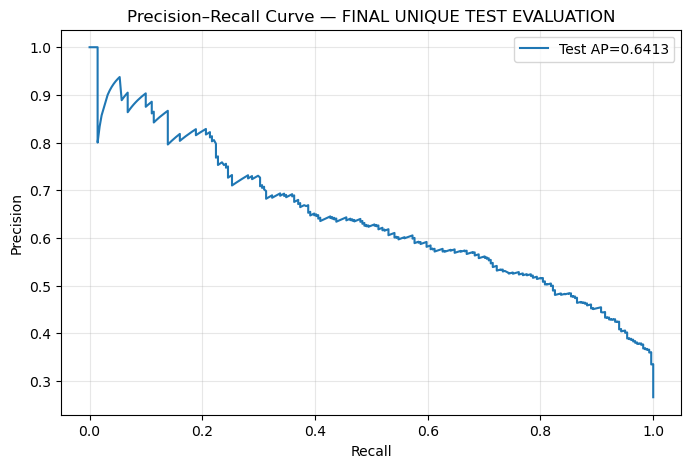

In [14]:
if not IDEMPOTENT_REUSE:
    probability_metrics = dict(final_evaluation.probability_metrics)
    pr_curve = dict(final_evaluation.precision_recall_curve)
    roc_curve_data = dict(final_evaluation.roc_curve)
    calibration_data = dict(final_evaluation.calibration_curve)
else:
    evidence_for_plots = json.loads(
        (PROJECT_ROOT / FINAL_DIR / "final-test-evidence.json").read_text(encoding="utf-8")
    )
    probability_metrics = evidence_for_plots["probability_metrics"]
    pr_curve = evidence_for_plots["precision_recall_curve"]
    roc_curve_data = evidence_for_plots["roc_curve"]
    calibration_data = evidence_for_plots["calibration_curve"]

fig, ax = plt.subplots()
ax.plot(pr_curve["recall"], pr_curve["precision"], label=f"Test AP={probability_metrics['average_precision']:.4f}")
ax.set_title("Precision–Recall Curve — FINAL UNIQUE TEST EVALUATION")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


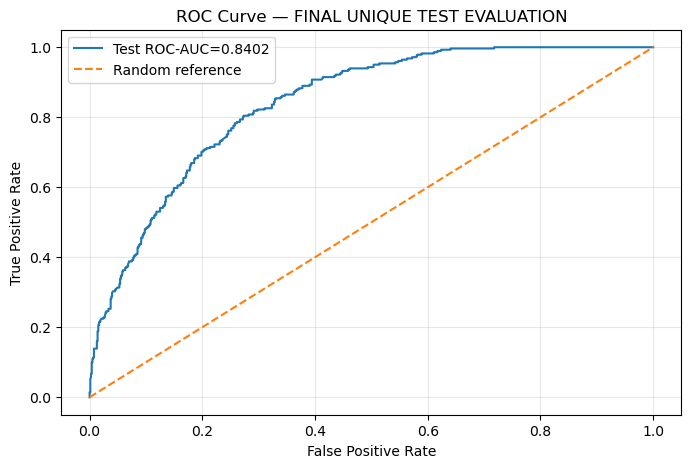

In [15]:
fig, ax = plt.subplots()
ax.plot(roc_curve_data["false_positive_rate"], roc_curve_data["true_positive_rate"], label=f"Test ROC-AUC={probability_metrics['roc_auc']:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Random reference")
ax.set_title("ROC Curve — FINAL UNIQUE TEST EVALUATION")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


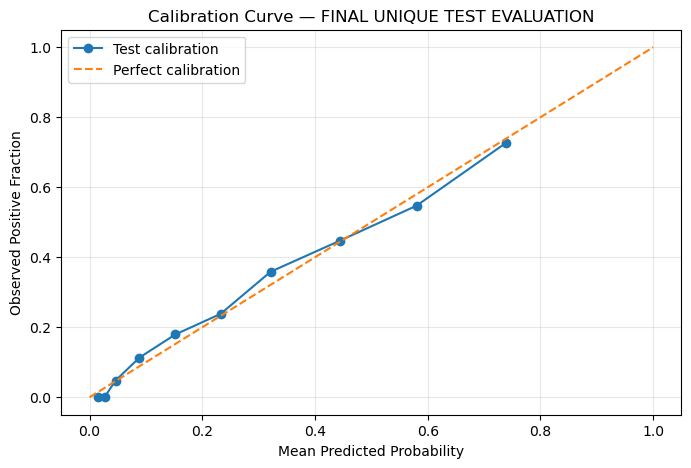

Interpretation: curves are final descriptive diagnostics only; no decision was changed after observing test.


In [16]:
fig, ax = plt.subplots()
ax.plot(calibration_data["mean_predicted_probability"], calibration_data["fraction_of_positives"], marker="o", label="Test calibration")
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.set_title("Calibration Curve — FINAL UNIQUE TEST EVALUATION")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Observed Positive Fraction")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Interpretation: curves are final descriptive diagnostics only; no decision was changed after observing test.")


## 15. Confusion Diagnostics

Compare confusion counts at the fixed default threshold and the previously frozen educational threshold.


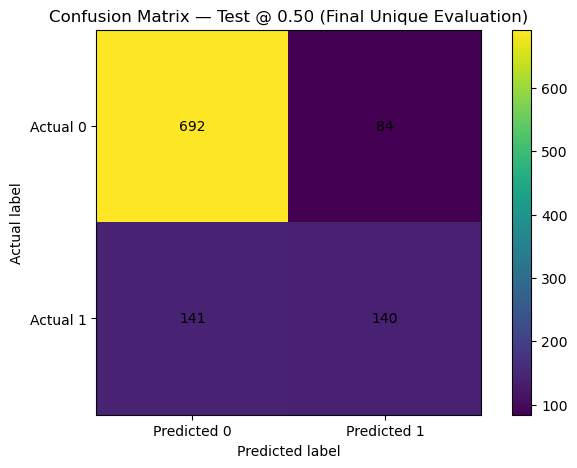

In [17]:
def plot_confusion(metrics: dict, title: str) -> None:
    matrix = [
        [metrics["true_negatives"], metrics["false_positives"]],
        [metrics["false_negatives"], metrics["true_positives"]],
    ]
    fig, ax = plt.subplots()
    image = ax.imshow(matrix)
    for row in range(2):
        for column in range(2):
            ax.text(column, row, str(matrix[row][column]), ha="center", va="center")
    ax.set_xticks([0, 1], labels=["Predicted 0", "Predicted 1"])
    ax.set_yticks([0, 1], labels=["Actual 0", "Actual 1"])
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    ax.set_title(title)
    fig.colorbar(image, ax=ax)
    plt.show()

plot_confusion(default_metrics, "Confusion Matrix — Test @ 0.50 (Final Unique Evaluation)")


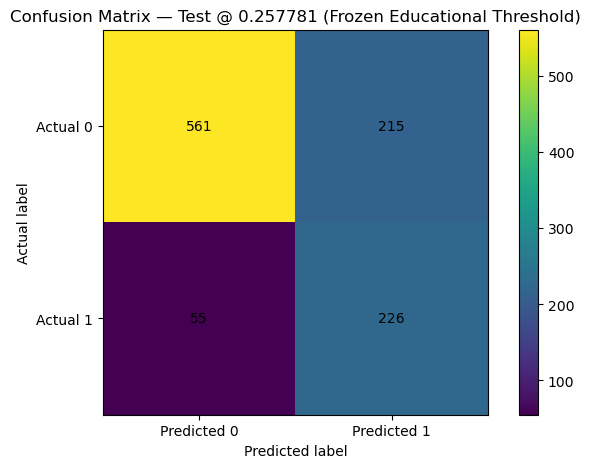

The educational threshold emphasizes recall but remains non-operational.


In [18]:
plot_confusion(
    educational_metrics,
    f"Confusion Matrix — Test @ {FINAL_CONTRACT.educational_threshold:.6f} (Frozen Educational Threshold)",
)
print("The educational threshold emphasizes recall but remains non-operational.")


## 16. Validation-to-Test Descriptive Comparison

Compare the selected validation metrics with final test metrics. These deltas are descriptive and cannot trigger new selection, tuning, or threshold changes.


In [19]:
if not IDEMPOTENT_REUSE:
    generalization_deltas = dict(final_evaluation.generalization_deltas)
else:
    generalization_deltas = evidence_for_plots["generalization_deltas"]

comparison = pd.DataFrame(
    {
        "validation": [
            model_selection_handoff["selected_validation_metrics"]["average_precision"],
            model_selection_handoff["selected_validation_metrics"]["roc_auc"],
            model_selection_handoff["selected_validation_metrics"]["brier_score"],
            model_selection_handoff["selected_validation_metrics"]["log_loss"],
        ],
        "test": [
            probability_metrics["average_precision"],
            probability_metrics["roc_auc"],
            probability_metrics["brier_score"],
            probability_metrics["log_loss"],
        ],
    },
    index=["Average Precision", "ROC-AUC", "Brier Score (lower is better)", "Log Loss (lower is better)"],
)
comparison


,validation,test
Average Precision,0.670821,0.641283
ROC-AUC,0.847749,0.840151
Brier Score (lower is better),0.133203,0.139422
Log Loss (lower is better),0.413481,0.420650


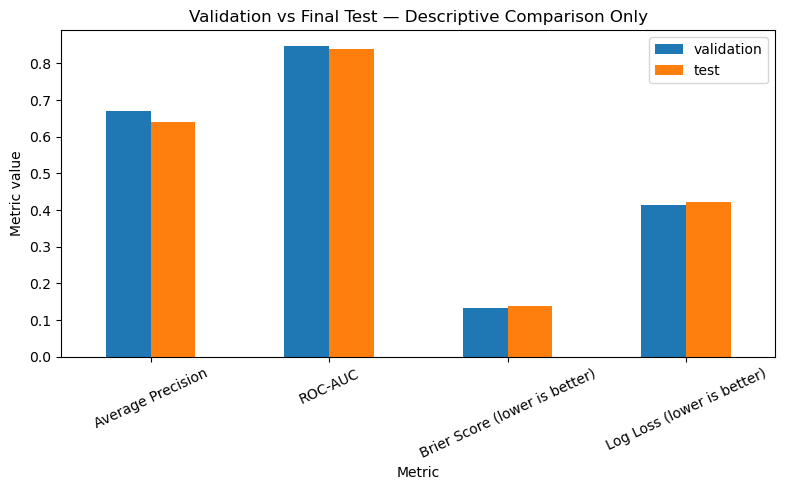

,test minus validation
average_precision_test_minus_validation,-0.029538
roc_auc_test_minus_validation,-0.007598
brier_score_test_minus_validation,0.006218
log_loss_test_minus_validation,0.007170
default_precision_test_minus_validation,-0.020570
default_recall_test_minus_validation,-0.048208
educational_precision_test_minus_validation,-0.001103
educational_recall_test_minus_validation,-0.006444


In [20]:
fig, ax = plt.subplots()
comparison.plot(kind="bar", ax=ax)
ax.set_title("Validation vs Final Test — Descriptive Comparison Only")
ax.set_ylabel("Metric value")
ax.set_xlabel("Metric")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame([generalization_deltas]).T.rename(columns={0: "test minus validation"})


## 17. Final Pipeline Serialization

Serialize the complete fitted pipeline—preprocessor and estimator together—to staging, validate its hash and fitted state, compare non-test round-trip probabilities, and promote it only as part of the atomic five-artifact transaction.


In [21]:
if not IDEMPOTENT_REUSE:
    print("Serialization will occur inside the atomic artifact transaction.")
    print("Round-trip validation sample source: train + validation only.")
else:
    print("Idempotent reuse: existing joblib hash and fitted pipeline were revalidated without test.")


Serialization will occur inside the atomic artifact transaction.
Round-trip validation sample source: train + validation only.


## 18. Inference Bundle Construction

Build a generic declarative bundle with feature order, dtypes, fitted categorical vocabularies, embedded preprocessing, trusted model hash, educational threshold semantics, and an explicitly unavailable operational prediction.


In [22]:
MODEL_SELECTION_FILENAMES = [
    "model-selection-manifest.json",
    "candidate-results.json",
    "cross-validation-results.csv",
    "validation-evidence.json",
    "threshold-analysis.json",
    "model-selection-handoff.json",
]
PREPARATION_FILENAMES = [
    "preparation-manifest.json",
    "feature-manifest.json",
    "split-manifest.json",
    "quality-evidence.json",
]

upstream_references = {
    "preparation": {
        "manifest_references": {
            filename: {
                "path": (PREPARATION_DIR / filename).as_posix(),
                "byte_sha256": sha256_file(PROJECT_ROOT / PREPARATION_DIR / filename),
            }
            for filename in PREPARATION_FILENAMES
        },
        "dataset_references": {
            "prepared": {
                "path": preparation_manifest["prepared_path"],
                "byte_sha256": preparation_manifest["prepared_sha256"],
            },
            "train": {
                "path": split_manifest["partition_paths"]["train"],
                "byte_sha256": split_manifest["partition_sha256"]["train"],
            },
            "validation": {
                "path": split_manifest["partition_paths"]["validation"],
                "byte_sha256": split_manifest["partition_sha256"]["validation"],
            },
            "test": {
                "path": split_manifest["partition_paths"]["test"],
                "byte_sha256": split_manifest["partition_sha256"]["test"],
            },
        },
        "feature_contract_fingerprint": model_selection_manifest["preparation_fingerprints"]["feature_contract_fingerprint"],
        "preparation_contract_fingerprint": model_selection_manifest["preparation_fingerprints"]["preparation_contract_fingerprint"],
    },
    "model_selection": {
        "artifact_references": {
            filename: {
                "path": (MODEL_SELECTION_DIR / filename).as_posix(),
                "byte_sha256": sha256_file(PROJECT_ROOT / MODEL_SELECTION_DIR / filename),
                "semantic_sha256": (
                    model_selection_manifest["self_semantic_sha256"]
                    if filename == "model-selection-manifest.json"
                    else model_selection_manifest["artifact_fingerprints"][filename]["semantic_sha256"]
                ),
            }
            for filename in MODEL_SELECTION_FILENAMES
        },
        "model_selection_manifest_self_semantic_sha256": model_selection_manifest["self_semantic_sha256"],
    },
}

expected_input_dtypes = {
    column: feature_manifest["expected_dtypes"]["prepared"][column]
    for column in FINAL_CONTRACT.feature_columns
}
missing_value_policy = {
    "preparation_rules": preparation_manifest["deterministic_rules"],
    "learned_imputation_in_final_pipeline": False,
    "invalid_conversion_counts": preparation_manifest["invalid_conversion_counts"],
}
print("Declarative bundle inputs prepared; no API-specific contract added.")


Declarative bundle inputs prepared; no API-specific contract added.


## 19. Atomic Artifact Materialization and Reload

Materialize the joblib plus four JSON artifacts as one atomic set, then reload and validate the manifest, evidence, bundle, handoff, and trusted pipeline. A complete equivalent rerun is reused without fitting or reevaluating `test`.


In [23]:
if not IDEMPOTENT_REUSE:
    write_result = write_final_model_artifacts(
        project_root=PROJECT_ROOT,
        output_directory=FINAL_DIR,
        pipeline=final_pipeline,
        contract=FINAL_CONTRACT,
        training_data=final_training,
        train_sha256=split_manifest["partition_sha256"]["train"],
        validation_sha256=split_manifest["partition_sha256"]["validation"],
        test_partition=test_partition,
        evaluation=final_evaluation,
        fit_duration_seconds=FIT_DURATION_SECONDS,
        upstream_references=upstream_references,
        preparation_handoff_references=upstream_references["preparation"],
        model_selection_handoff_references=upstream_references["model_selection"],
        validation_metrics=model_selection_handoff["selected_validation_metrics"],
        validation_educational_threshold=model_selection_handoff["selected_educational_threshold"],
        expected_input_dtypes=expected_input_dtypes,
        missing_value_policy=missing_value_policy,
        overwrite=False,
    )
    print("Atomic artifact set created:", list(write_result.created))
else:
    print("Idempotent reuse: no artifact was rewritten.")

final_handoff = load_and_validate_final_model_handoff(
    project_root=PROJECT_ROOT,
    handoff_path=FINAL_DIR / "final-model-handoff.json",
)
inference_bundle = load_and_validate_inference_bundle(
    project_root=PROJECT_ROOT,
    bundle_path=FINAL_DIR / "inference-bundle.json",
)
reloaded_pipeline = load_trusted_pipeline_from_bundle(
    project_root=PROJECT_ROOT,
    bundle=inference_bundle,
)
final_manifest = json.loads(
    (PROJECT_ROOT / FINAL_DIR / "final-model-manifest.json").read_text(encoding="utf-8")
)
final_test_evidence = json.loads(
    (PROJECT_ROOT / FINAL_DIR / "final-test-evidence.json").read_text(encoding="utf-8")
)

if not IDEMPOTENT_REUSE:
    sample = final_training.features.iloc[:32].copy(deep=True)
    assert (final_pipeline.predict_proba(sample) == reloaded_pipeline.predict_proba(sample)).all()

print("Final handoff valid.")
print("Inference bundle valid.")
print("Trusted pipeline reloaded:", type(reloaded_pipeline).__name__)
print("Model SHA-256:", inference_bundle["model_artifact_sha256"])
print("Model state fingerprint:", inference_bundle["model_state_fingerprint"])
print("Test evaluation count:", final_handoff["test_partition_evaluation_count"])


Atomic artifact set created: ['final-pipeline.joblib', 'final-model-manifest.json', 'final-test-evidence.json', 'inference-bundle.json', 'final-model-handoff.json']
Final handoff valid.
Inference bundle valid.
Trusted pipeline reloaded: Pipeline
Model SHA-256: 48da4c7aa56d5d08090e808f551f555740d18e791af39c4c3f373467ec296b8c
Model state fingerprint: c9328311e2ed5953b5aab1abc17b439ff7e90c7c8e4f15b6a31598d05dc771e6
Test evaluation count: 1


## 20. Notebook 05 Handoff and Limitations

Notebook 05 may validate this handoff and bundle, load the trusted pipeline, and demonstrate inference on independent inputs. It must not refit the model, use test data, or present the educational threshold as an operational policy.


In [24]:
readiness = {
    key: final_handoff[key]
    for key in (
        "educational_final_model_completed",
        "final_model_trained",
        "final_test_evaluation_completed",
        "model_artifact_materialized",
        "model_bundle_materialized",
        "final_model_handoff_ready",
        "educational_inference_demo_ready",
        "test_partition_evaluated",
        "test_partition_evaluation_count",
        "test_partition_used_for_adjustment",
        "operational_modeling_ready",
        "operational_validity",
        "temporal_contract_status",
        "feature_inference_availability",
        "operational_threshold",
        "api_implemented",
    )
}
print(json.dumps(readiness, indent=2, sort_keys=True))
print("Limitations:")
for limitation in final_manifest["limitations"]:
    print("-", limitation)
print("Notebook 05 handoff is ready for educational inference demonstration only.")


{
  "api_implemented": false,
  "educational_final_model_completed": true,
  "educational_inference_demo_ready": true,
  "feature_inference_availability": "unconfirmed",
  "final_model_handoff_ready": true,
  "final_model_trained": true,
  "final_test_evaluation_completed": true,
  "model_artifact_materialized": true,
  "model_bundle_materialized": true,
  "operational_modeling_ready": false,
  "operational_threshold": "unresolved",
  "operational_validity": "unconfirmed",
  "temporal_contract_status": "unresolved",
  "test_partition_evaluated": true,
  "test_partition_evaluation_count": 1,
  "test_partition_used_for_adjustment": false
}
Limitations:
- Educational snapshot validation only.
- Operational validity is unconfirmed.
- Operational threshold remains unresolved.
Notebook 05 handoff is ready for educational inference demonstration only.
